# AI Job Market — Employment Dynamics & Company Profiles
**Author**: Rendy Herdianto  
**Date**: 2026-03-31  
**Dataset**: [AI Job Market Insights](/kaggle/input/ai-job-market-trends)

---

## Description
This notebook analyses the employment structure and company profiles within AI job postings
(September 2023 – September 2025). It examines how employment types are distributed,
how the experience mix varies across company sizes, and what salary premiums different
employment arrangements carry.

## Objectives
1. Understand the split between Full-time, Contract, Remote, and Internship roles
2. Profile company size distribution and associated salary ranges
3. Analyse experience level mix within each company size tier
4. Examine employment type share by industry
5. Surface the posting volume heatmap across company size × experience level

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preparation](#3-data-preparation)
4. [Employment Type Distribution](#4-employment-type-distribution)
5. [Company Size Distribution](#5-company-size-distribution)
6. [Experience Level Distribution](#6-experience-level-distribution)
7. [Experience Mix by Company Size](#7-experience-mix-by-company-size)
8. [Employment Type by Industry](#8-employment-type-by-industry)
9. [Salary by Employment Type](#9-salary-by-employment-type)
10. [Key Insights](#10-key-insights)

## 1. Environment Setup

In [1]:
import subprocess, sys
for pkg in ["loguru"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

In [2]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
FIGURE_SIZE = (12, 5)
PALETTE     = "viridis"

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": FIGURE_SIZE})
print("Environment ready.")

Environment ready.


In [3]:
# ── Dataset Sources ───────────────────────────────────────────────────────────
import os

# Resolve project root — works whether CWD is project root or notebooks/03_analysis/
_cwd = Path(os.path.abspath(""))
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parents[1]

KAGGLE_PATH   = Path("/kaggle/input/ai-job-market-insights/ai_job_market.csv")
ENRICHED_PATH = PROJECT_ROOT / "data/enriched/ai_job_market_enriched.csv"
RAW_PATH      = PROJECT_ROOT / "data/raw/ai_job_market.csv"


def resolve_dataset_path() -> tuple[Path, bool]:
    if KAGGLE_PATH.exists():   return KAGGLE_PATH, True
    if ENRICHED_PATH.exists(): return ENRICHED_PATH, False
    if RAW_PATH.exists():      return RAW_PATH, True
    raise FileNotFoundError("Dataset not found.")


DATASET_PATH, IS_RAW = resolve_dataset_path()
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset     : {DATASET_PATH}  |  raw_mode={IS_RAW}")


Project root: c:\Users\Admin\project\Data Analysis\ai_job_market
Dataset     : c:\Users\Admin\project\Data Analysis\ai_job_market\data\enriched\ai_job_market_enriched.csv  |  raw_mode=False


In [4]:
def save_fig(name, dpi=150):
    if not Path("/kaggle").exists():
        out = Path("outputs/figures")
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=dpi, bbox_inches="tight")

def fmt_usd(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

def palette(n):
    return sns.color_palette(PALETTE, n_colors=n).as_hex()

## 2. Dataset Overview

In [5]:
parse_dates = None if IS_RAW else ["posted_date"]
df_raw = pd.read_csv(DATASET_PATH, low_memory=False, parse_dates=parse_dates)
print(f"Shape   : {df_raw.shape}")
df_raw.head(3)

Shape   : (2000, 21)


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_count,posted_year,posted_month,posted_quarter,days_since_posted,experience_order
0,1,Foster and Sons,Healthcare,Data Analyst,numpy;reinforcement learning;pytorch;scikit-le...,Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,kdb+;langchain,"92,860.00","109,598.00","101,229.00",6,2025,8,3,41,1
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,scikit-learn;cuda;sql;pandas,Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,fastapi;kdb+;tensorflow,"78,523.00","144,875.00","111,699.00",4,2024,3,1,557,2
2,3,King Inc,Tech,Quant Researcher,mlflow;fastapi;azure;pytorch;sql;gcp,Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,bigquery;pytorch;scikit-learn,"124,496.00","217,204.00","170,850.00",6,2025,9,3,12,0


## 3. Data Preparation

In [6]:
df = df_raw.copy()

if IS_RAW:
    if "salary_range_usd" in df.columns:
        def _parse_min(s):
            m = re.search(r"(\d+)", str(s).replace(",", ""))
            return float(m.group(1)) if m else None
        def _parse_max(s):
            m = re.search(r"-\s*(\d+)", str(s).replace(",", ""))
            return float(m.group(1)) if m else None
        df["salary_min"] = df["salary_range_usd"].apply(_parse_min)
        df["salary_max"] = df["salary_range_usd"].apply(_parse_max)
        mask = df["salary_min"].notna() & df["salary_max"].notna()
        df.loc[mask, "salary_avg"] = (df.loc[mask, "salary_min"] + df.loc[mask, "salary_max"]) / 2

for col in ["experience_level", "employment_type", "company_size", "industry"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print(f"Working dataset: {df.shape}")
print("Null counts:")
print(df[["experience_level", "employment_type", "company_size"]].isnull().sum())

Working dataset: (2000, 21)
Null counts:
experience_level    0
employment_type     0
company_size        0
dtype: int64


## 4. Employment Type Distribution

The donut chart below shows the share of postings across employment types.
**Full-time** positions dominate the AI job market, reflecting the preference
for dedicated on-team practitioners rather than project-based contractors.

In [7]:
emp_counts = df["employment_type"].value_counts().reset_index()
emp_counts.columns = ["employment_type", "count"]
emp_counts["share_pct"] = (emp_counts["count"] / emp_counts["count"].sum() * 100).round(2)
emp_counts

,employment_type,count,share_pct
0,Internship,574,28.70
1,Full-time,509,25.45
2,Contract,465,23.25
3,Remote,452,22.60


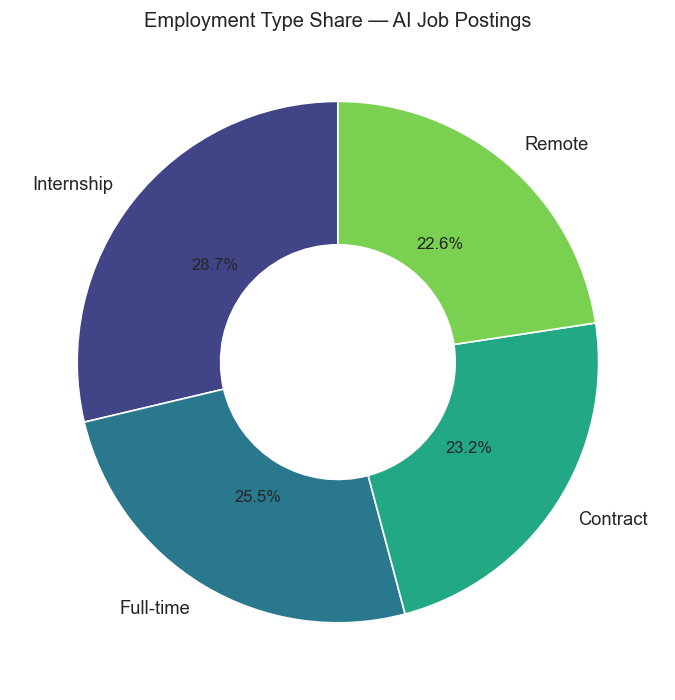

In [8]:
colors = palette(len(emp_counts))
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autos = ax.pie(
    emp_counts["count"],
    labels=emp_counts["employment_type"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width": 0.55},
)
for at in autos:
    at.set_fontsize(10)
ax.set_title("Employment Type Share — AI Job Postings")
plt.tight_layout()
save_fig("employment_type_share.png")
plt.show()

**Insight**: The overwhelming share of **Full-time** postings confirms that AI practitioners
are primarily employed as permanent staff rather than contractors. **Contract** roles represent
growth opportunities for specialists who prefer project-based work, often commanding higher
hourly rates in exchange for job security. **Internship** volume indicates a healthy pipeline
of entry-level talent development across the industry.

## 5. Company Size Distribution

The bar chart shows how postings are distributed across Startup, Mid-size, and
Large companies. This reflects where AI hiring activity is concentrated.

In [9]:
size_order = ["Startup", "Mid", "Large"]
size_counts = (
    df["company_size"].value_counts()
    .reindex(size_order, fill_value=0)
    .reset_index()
)
size_counts.columns = ["company_size", "count"]
size_counts["share_pct"] = (size_counts["count"] / size_counts["count"].sum() * 100).round(2)
size_counts

,company_size,count,share_pct
0,Startup,672,33.60
1,Mid,671,33.55
2,Large,657,32.85


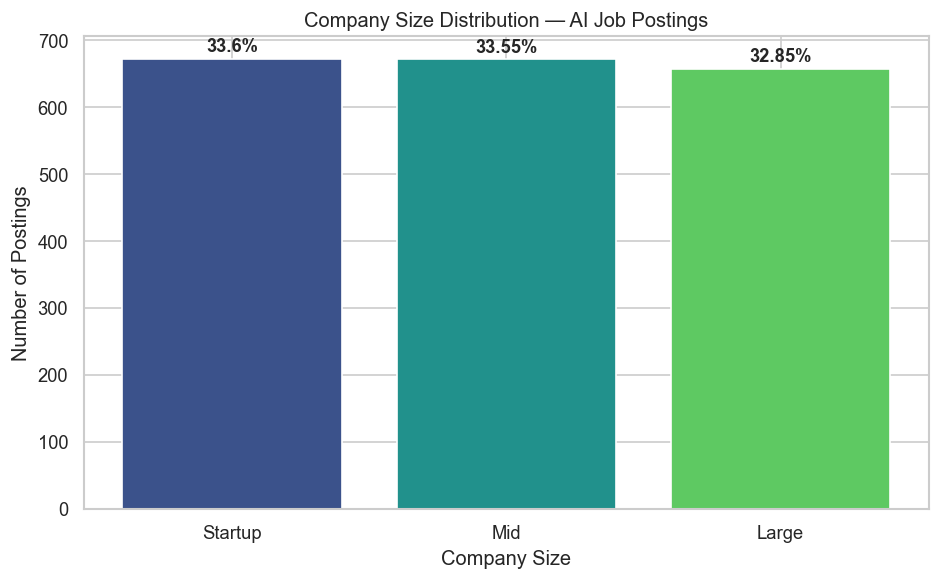

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(size_counts["company_size"], size_counts["count"],
              color=palette(len(size_counts)))

for bar, pct in zip(bars, size_counts["share_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{pct}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Company Size Distribution — AI Job Postings")
ax.set_xlabel("Company Size")
ax.set_ylabel("Number of Postings")
plt.tight_layout()
save_fig("company_size_distribution.png")
plt.show()

**Insight**: The distribution across company sizes indicates where job seekers are most
likely to find opportunities. A strong **Large company** share suggests established
enterprises are the primary AI talent consumers; significant **Startup** volume signals
that early-stage companies are actively competing for the same talent pool.

## 6. Experience Level Distribution

Understanding whether the market demands mostly Entry, Mid, or Senior talent
helps both job seekers gauge competitiveness and companies understand candidate
pipeline dynamics.

In [11]:
exp_order = ["Entry", "Mid", "Senior"]
exp_counts = (
    df["experience_level"].value_counts()
    .reindex(exp_order, fill_value=0)
    .reset_index()
)
exp_counts.columns = ["experience_level", "count"]
exp_counts["share_pct"] = (exp_counts["count"] / exp_counts["count"].sum() * 100).round(2)
exp_counts

,experience_level,count,share_pct
0,Entry,702,35.10
1,Mid,668,33.40
2,Senior,630,31.50


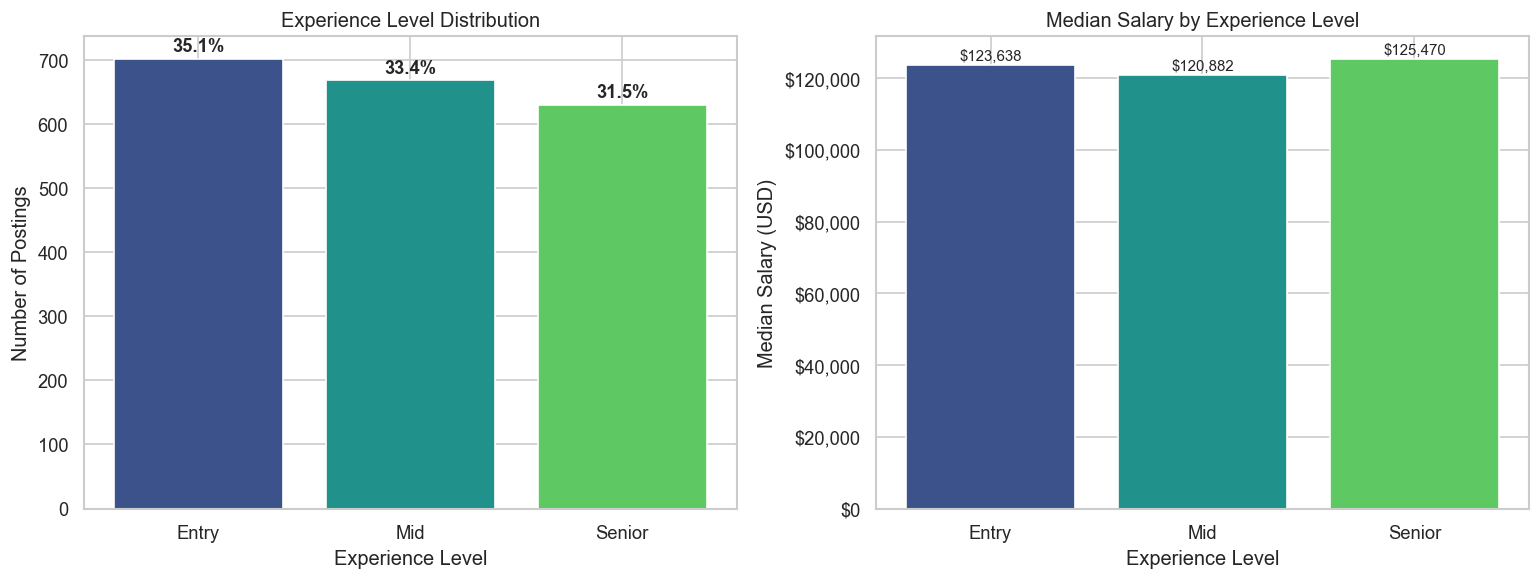

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
ax = axes[0]
bars = ax.bar(exp_counts["experience_level"], exp_counts["count"],
              color=palette(len(exp_counts)))
for bar, pct in zip(bars, exp_counts["share_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{pct}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Experience Level Distribution")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Number of Postings")

# Salary by experience (median bar)
ax2 = axes[1]
if "salary_avg" in df.columns:
    medians = (
        df.dropna(subset=["salary_avg", "experience_level"])
        .groupby("experience_level")["salary_avg"]
        .median()
        .reindex(exp_order)
    )
    bars2 = ax2.bar(medians.index, medians.values, color=palette(len(medians)))
    for bar, val in zip(bars2, medians.values):
        if not np.isnan(val):
            ax2.text(bar.get_x() + bar.get_width() / 2, val + 500,
                     f"${val:,.0f}", ha="center", va="bottom", fontsize=9)
    fmt_usd(ax2, "y")
    ax2.set_title("Median Salary by Experience Level")
    ax2.set_xlabel("Experience Level")
    ax2.set_ylabel("Median Salary (USD)")

plt.tight_layout()
save_fig("experience_level_distribution.png")
plt.show()

**Insight**: The balance between experience levels answers a critical supply-demand question.
If **Senior** postings dominate, the market is competitive for entry-level candidates and
companies face talent scarcity at the top. A high **Entry** share indicates companies are
investing in development pipelines and the graduate market is accessible. The paired salary
chart confirms the compensation step-up associated with each tier.

## 7. Experience Mix by Company Size

The stacked bar chart shows what fraction of each company size tier's postings
target Entry, Mid, or Senior candidates. This reveals whether startups or large
companies are more likely to hire juniors vs. seniors.

In [13]:
pivot = (
    df.groupby(["company_size", "experience_level"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=size_order, columns=exp_order, fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.round(1)

experience_level,Entry,Mid,Senior
company_size,,,
Startup,32.70,30.80,36.50
Mid,37.30,32.30,30.40
Large,35.30,37.10,27.50


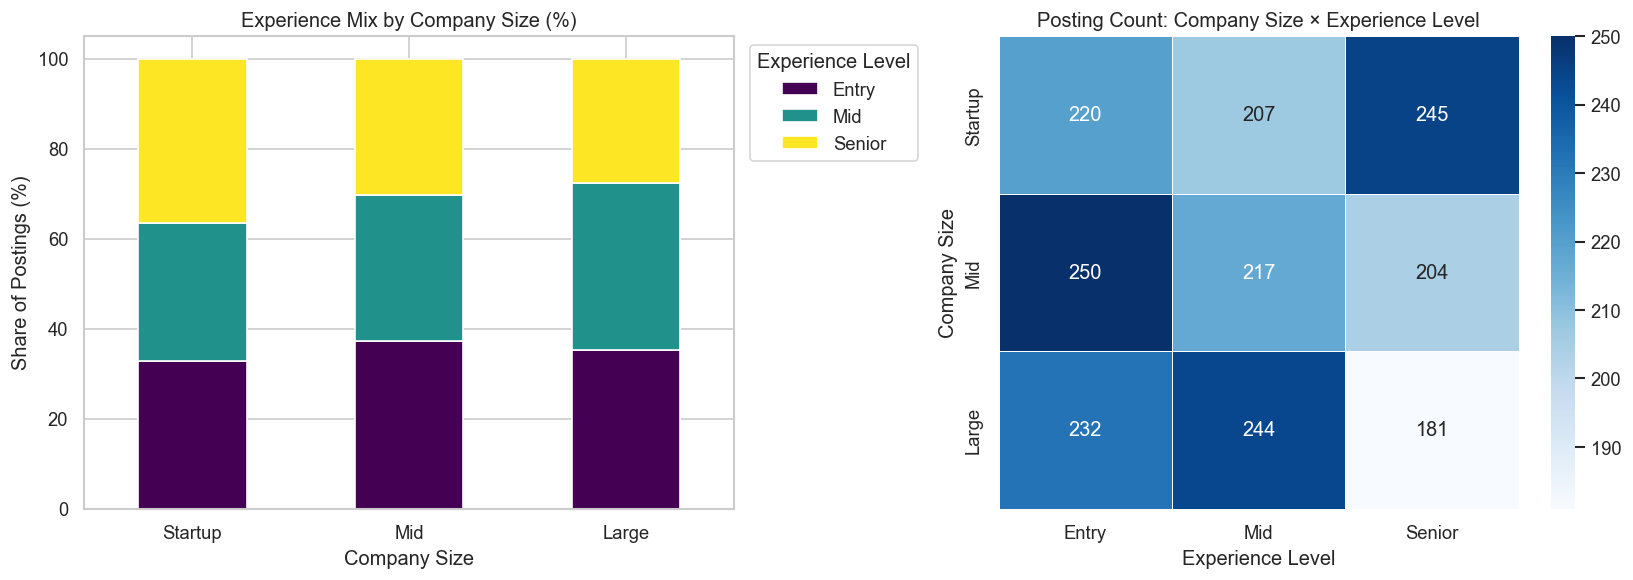

In [14]:
# Raw counts heatmap
count_pivot = pivot.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — percentage
ax = axes[0]
pivot_pct.plot(kind="bar", stacked=True, ax=ax, colormap=PALETTE)
ax.set_title("Experience Mix by Company Size (%)")
ax.set_xlabel("Company Size")
ax.set_ylabel("Share of Postings (%)")
ax.legend(title="Experience Level", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=0)

# Heatmap — raw counts
ax2 = axes[1]
sns.heatmap(
    count_pivot, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=ax2,
)
ax2.set_title("Posting Count: Company Size × Experience Level")
ax2.set_xlabel("Experience Level")
ax2.set_ylabel("Company Size")

plt.tight_layout()
save_fig("experience_mix_by_company_size.png")
plt.show()

**Insight**: **Startups** tend to have a higher share of Senior postings relative to their
total — early-stage companies often need experienced practitioners who can operate
independently with limited infrastructure. **Large companies** can afford more Entry and
Mid hires, supported by structured onboarding and established mentorship programmes.
This pattern has direct implications for where different experience cohorts should focus
their job search.

## 8. Employment Type by Industry

The stacked bar chart shows how employment type share differs across industries.
Industries with higher contract ratios may signal project-driven or regulatory-constrained
hiring patterns.

In [15]:
ind_emp = (
    df.groupby(["industry", "employment_type"])
    .size()
    .unstack(fill_value=0)
)
ind_emp_pct = ind_emp.div(ind_emp.sum(axis=1), axis=0) * 100
ind_emp_pct.round(1)

employment_type,Contract,Full-time,Internship,Remote
industry,,,,
Automotive,24.00,24.00,30.00,22.00
E-commerce,25.10,20.30,27.80,26.80
Education,23.50,23.80,31.00,21.80
Finance,25.40,24.00,23.70,26.90
Healthcare,20.80,31.20,27.90,20.10
Retail,20.10,28.70,28.00,23.20
Tech,23.70,26.60,32.50,17.20


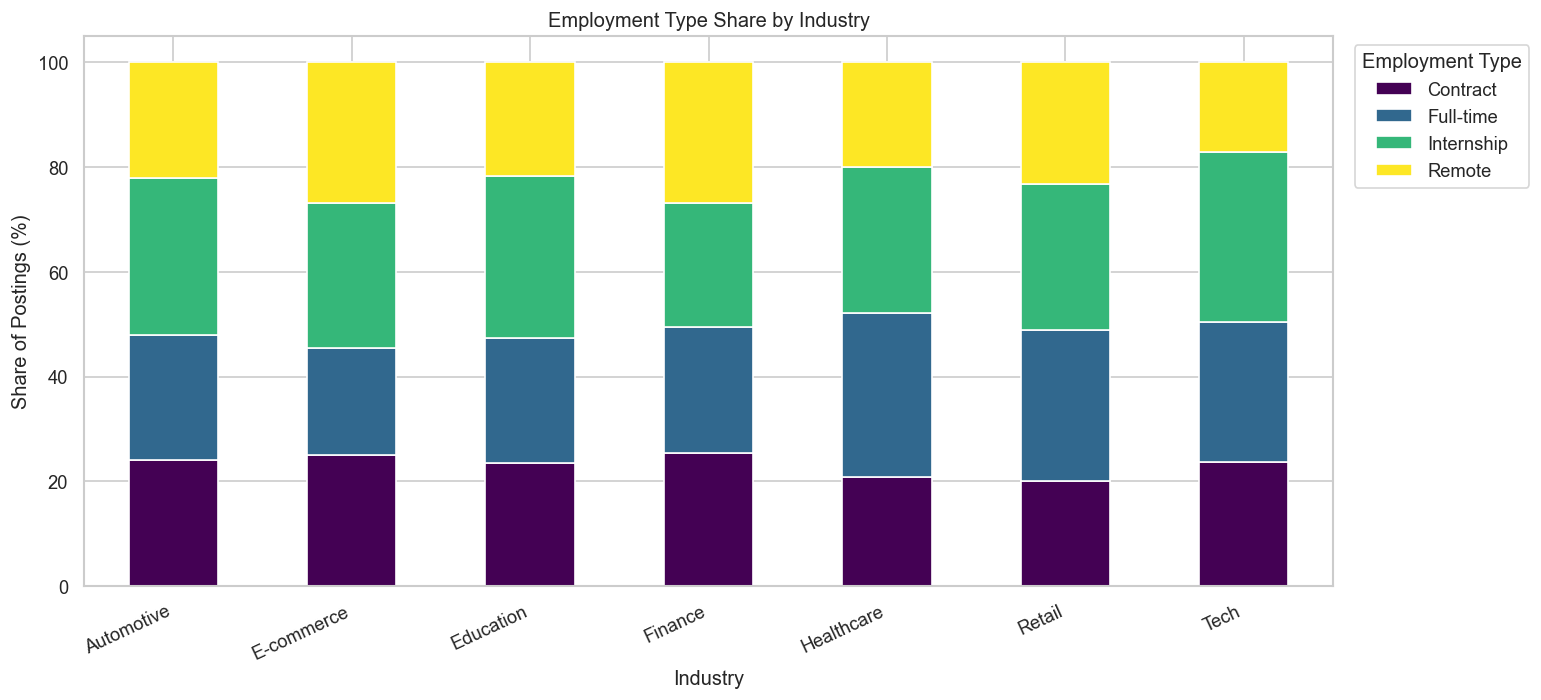

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))
ind_emp_pct.plot(kind="bar", stacked=True, ax=ax, colormap=PALETTE)

ax.set_title("Employment Type Share by Industry")
ax.set_xlabel("Industry")
ax.set_ylabel("Share of Postings (%)")
ax.legend(title="Employment Type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
save_fig("employment_type_by_industry.png")
plt.show()

**Insight**: Industries with a higher **Contract** or **Remote** share indicate more
flexible or distributed talent models — often seen in **Finance** and **Tech** where
specialist projects are common. **Healthcare** and **Education** sectors typically
show higher permanent employment ratios, reflecting regulatory requirements and
the need for long-term institutional knowledge.

## 9. Salary by Employment Type

Box plots compare salary distributions across employment types. This helps candidates
understand the financial trade-offs of choosing contract work, remote arrangements,
or traditional full-time employment.

In [17]:
if "salary_avg" in df.columns:
    emp_sal = (
        df.dropna(subset=["salary_avg", "employment_type"])
        .groupby("employment_type")["salary_avg"]
        .agg(count="count", mean="mean", median="median", std="std")
        .round(0)
        .sort_values("median", ascending=False)
        .reset_index()
    )
    display(emp_sal)

,employment_type,count,mean,median,std
0,Internship,574,"124,213.00","125,454.00","34,742.00"
1,Remote,452,"122,150.00","123,071.00","34,865.00"
2,Full-time,509,"123,706.00","122,933.00","33,274.00"
3,Contract,465,"121,728.00","120,173.00","36,350.00"


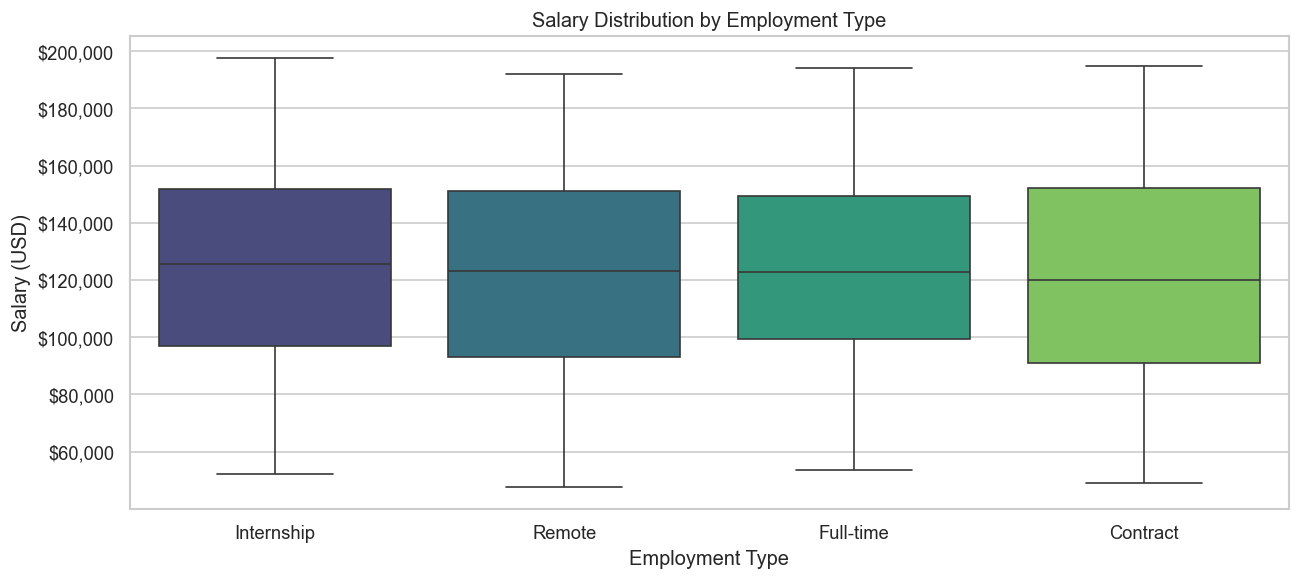

In [18]:
if "salary_avg" in df.columns:
    emp_order_sal = (
        df.dropna(subset=["salary_avg", "employment_type"])
        .groupby("employment_type")["salary_avg"]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(
        data=df.dropna(subset=["salary_avg", "employment_type"]),
        x="employment_type",
        y="salary_avg",
        order=emp_order_sal,
        palette=palette(len(emp_order_sal)),
        ax=ax,
    )
    ax.set_title("Salary Distribution by Employment Type")
    ax.set_xlabel("Employment Type")
    ax.set_ylabel("Salary (USD)")
    fmt_usd(ax)
    plt.tight_layout()
    save_fig("salary_by_employment_type.png")
    plt.show()

**Insight**: **Contract roles** often show a wide salary range — the top end reflects
specialised consultants commanding premium rates, while the lower end includes short-term
placements at junior levels. **Full-time** salaries tend to cluster more tightly around
established pay grades. **Internship** compensation is predictably lower but provides the
invaluable entry point into the industry.

## 10. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Full-time roles dominate AI postings | Candidates seeking stability should focus their search on permanent roles |
| 2 | Large companies are the primary AI talent consumers | Entry/Mid candidates benefit most from targeting established enterprises |
| 3 | Startups over-index on Senior hires relative to company size | Experienced practitioners offer Startups a lower-risk, higher-impact hire |
| 4 | Industry employment type mix varies significantly | Finance/Tech offer more contract flexibility; Healthcare/Education favour permanent roles |
| 5 | Contract arrangements can match or exceed Full-time salaries at the high end | Contractors with specialised skills can command premium rates |

---
*Analysis based on AI job market dataset (Sep 2023 – Sep 2025).*